In [42]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
import plotly.express as px
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Loading Datatset

In [9]:
data = fetch_california_housing()

In [10]:
data.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [11]:
X = data.data
y = data.target

In [12]:
X[0]

array([   8.3252    ,   41.        ,    6.98412698,    1.02380952,
        322.        ,    2.55555556,   37.88      , -122.23      ])

# ---> PCA Visualization

In [30]:
pca = PCA(n_components=2)

x_pca = pca.fit_transform(X)
pca_df = pd.DataFrame(
    x_pca,
    columns = ['C1', 'C2']
)

fig = px.scatter(
    pca_df,
    x = 'C1',
    y = 'C2',
    title = 'PCA Visualization of Data'
)
fig.show()
fig.write_image("../visualizations/regression/distribution_pca_2d.png")

# Train Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42
)

# Implementation

In [32]:
class KNN:

    def __init__(self, k:int, metric:str):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train_data = X
        self.y_train_data = y

    def euclidean(self, predict_sample):
        return np.sqrt(np.sum((self.X_train_data - predict_sample) ** 2, axis=1))

    def manhattan(self, predict_sample):
        return np.sum(abs(self.X_train_data - predict_sample), axis=1)
    
    def predict(self, X):
        distance = getattr(self, self.metric)
        predictions = []

        for predict_sample in X:
            distances = distance(predict_sample)
            
            k_indices = np.argsort(distances)[:self.k]
            k_values = self.y_train_data[k_indices]
            prediction = k_values.mean()

            predictions.append(prediction)

        return np.array(predictions)

# ---> Getting Optimum K : m-fold Cross Validation

In [15]:
kf = KFold(
    n_splits = 5,
    shuffle = True,
    random_state=42
)

## For MyModel

In [35]:
errors = {}

for k in range(5,30):
    print(f"Checking for k:{k}")
    model = KNN(k=k, metric='euclidean')
    fold_errors = []

    for train_idx, val_idx in kf.split(X_train):
        scaler = StandardScaler()

        X_fold_train = scaler.fit_transform(X_train[train_idx])
        X_fold_val = scaler.transform(X_train[val_idx])
        
        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]

        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)

        fold_errors.append(mean_squared_error(y_fold_val, preds))

    errors[k] = np.mean(fold_errors)

Checking for k:5
Checking for k:6
Checking for k:7
Checking for k:8
Checking for k:9
Checking for k:10
Checking for k:11
Checking for k:12
Checking for k:13
Checking for k:14
Checking for k:15
Checking for k:16
Checking for k:17
Checking for k:18
Checking for k:19
Checking for k:20
Checking for k:21
Checking for k:22
Checking for k:23
Checking for k:24
Checking for k:25
Checking for k:26
Checking for k:27
Checking for k:28
Checking for k:29


In [36]:
def see_optimum_k(errors, model_name):
    errors_df = pd.DataFrame(
        errors.items(),
        columns = ['k_value', 'mse']
    )

    fig = px.line(
        errors_df,
        x = 'k_value',
        y = 'mse',
        title = 'MSE per k value'
    )
    fig.show()
    fig.write_image(f"../visualizations/regression/optimum_k_{model_name}.png")

In [37]:
see_optimum_k(errors, 'scratch_implemented')

Let's choose k = 12

In [38]:
optimum_k = 12

## For SklearnModel

In [39]:
errors = {}
for k in range(5,30):
    print(f"Checking for k:{k}")
    fold_errors = []
    model = KNeighborsRegressor(
        n_neighbors = k,
        metric = 'minkowski',
        p=2
    )

    for train_idx, val_idx in kf.split(X_train):
        scaler = StandardScaler()

        X_fold_train = scaler.fit_transform(X_train[train_idx])
        X_fold_val = scaler.transform(X_train[val_idx])
        
        y_fold_train = y_train[train_idx]
        y_fold_val = y_train[val_idx]

        model.fit(X_fold_train, y_fold_train)
        preds = model.predict(X_fold_val)
        fold_errors.append(mean_squared_error(y_fold_val, preds))

    errors[k] = np.mean(fold_errors)

Checking for k:5
Checking for k:6
Checking for k:7
Checking for k:8
Checking for k:9
Checking for k:10
Checking for k:11
Checking for k:12
Checking for k:13
Checking for k:14
Checking for k:15
Checking for k:16
Checking for k:17
Checking for k:18
Checking for k:19
Checking for k:20
Checking for k:21
Checking for k:22
Checking for k:23
Checking for k:24
Checking for k:25
Checking for k:26
Checking for k:27
Checking for k:28
Checking for k:29


In [41]:
see_optimum_k(errors, 'sklearn_model')

k value obtained as 12

# ---> Feature Scaling

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---> Performance of Models

In [27]:
def print_model_error(model, k, metric, scaled, error):
    print(f"{'Scaled' if scaled else 'Unscaled'}  data | MSE on k:{k} and distance method: {metric} = ", round(error, 3))

## MyModel Performance

### i) euclidean distance

In [101]:
model = KNN(k=optimum_k, metric='euclidean')

# Prediction on Unscaled Data
model.fit(X_train, y_train)
preds = model.predict(X_test)
print_model_error(model, optimum_k, 'euclidean', 0, mean_squared_error(y_test, preds))

# Prediction on Scaled Data
model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)
print_model_error(model, optimum_k, 'euclidean', 1, mean_squared_error(y_test, preds))

Unscaled  data | MSE on k:12 and distance method: euclidean =  1.13
Scaled  data | MSE on k:12 and distance method: euclidean =  0.412


### ii) manhattan distance

In [102]:
model = KNN(k=optimum_k, metric='manhattan')

# Prediction on Unscaled Data
model.fit(X_train, y_train)
preds = model.predict(X_test)
print_model_error(model, optimum_k, 'manhattan', 0, mean_squared_error(y_test, preds))

# Prediction on Scaled Data
model.fit(X_train_scaled, y_train)
preds = model.predict(X_test_scaled)
print_model_error(model, optimum_k, 'manhattan', 1, mean_squared_error(y_test, preds))

Unscaled  data | MSE on k:12 and distance method: manhattan =  1.006
Scaled  data | MSE on k:12 and distance method: manhattan =  0.367


### iii) In PCA Space

In [43]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [44]:
model = KNN(k=optimum_k, metric = 'manhattan')
model.fit(X_train_pca, y_train)
preds = model.predict(X_test_pca)
print_model_error(model, optimum_k, 'manhattan', 0, mean_squared_error(y_test, preds))

Unscaled  data | MSE on k:12 and distance method: manhattan =  1.403


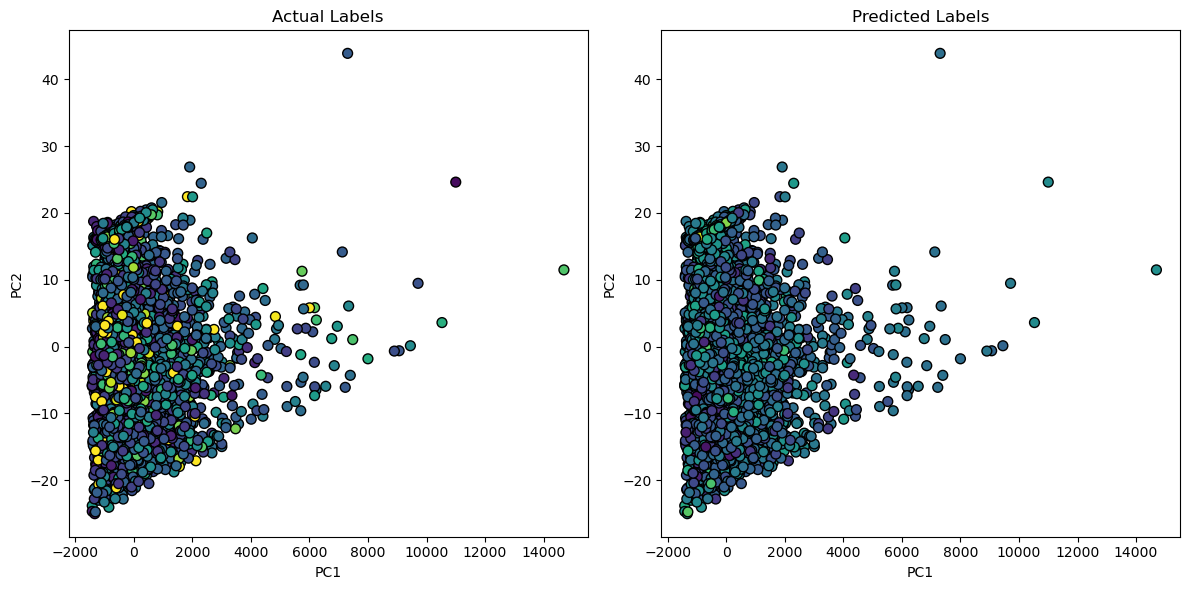

In [49]:
fig, ax = plt.subplots(1, 2, figsize = (12,6))

ax[0].scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c = y_test,
    cmap = 'viridis',
    edgecolor = 'k',
    s=50
)
ax[0].set_title("Actual Labels")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

ax[1].scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c = preds,
    cmap = 'viridis',
    edgecolor = "k",
    s=50
)
ax[1].set_title("Predicted Labels")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()
fig.savefig("../visualizations/regression/predictions_2d_pca.png")

## SklearnModel Performance

### euclidean

In [104]:
sklearn_model = KNeighborsRegressor(
    n_neighbors=11,
    metric='euclidean'
)

# Prediction on Unscaled Data
sklearn_model.fit(X_train, y_train)
preds = sklearn_model.predict(X_test)
print_model_error(model, optimum_k, 'euclidean', 0, mean_squared_error(y_test, preds))

# Prediction on Scaled Data
sklearn_model.fit(X_train_scaled, y_train)
preds = sklearn_model.predict(X_test_scaled)
print_model_error(model, optimum_k, 'euclidean', 1, mean_squared_error(y_test, preds))

Unscaled  data | MSE on k:12 and distance method: euclidean =  1.126
Scaled  data | MSE on k:12 and distance method: euclidean =  0.413


### manhattan

In [105]:
model = KNeighborsRegressor(
    n_neighbors=11,
    metric='manhattan'
)

# Prediction on Unscaled Data
sklearn_model.fit(X_train, y_train)
preds = sklearn_model.predict(X_test)
print_model_error(model, optimum_k, 'manhattan', 0, mean_squared_error(y_test, preds))

# Prediction on Scaled Data
sklearn_model.fit(X_train_scaled, y_train)
preds = sklearn_model.predict(X_test_scaled)
print_model_error(model, optimum_k, 'manhattan', 1, mean_squared_error(y_test, preds))

Unscaled  data | MSE on k:12 and distance method: manhattan =  1.126
Scaled  data | MSE on k:12 and distance method: manhattan =  0.413


In [19]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

model = KNN(k=12, metric='euclidean')

model.fit(X_train_pca, y_train)
preds = model.predict(X_test_pca)

In [ ]:
print_model_error(model, 12, 'euclidean', 0, mean_squared_error(y_test, preds))

Unscaled  data | MSE on k:12 and distance method: euclidean =  1.409
